# 22DM015 Final Project — Financial PhraseBank
## Part 3 — Full-dataset SOA comparison

**Dataset:** `takala/financial_phrasebank`, config `sentences_allagree` (2,264 sentences).‍
**Labels:** 0 = negative, 1 = neutral, 2 = positive.‍

### Shared data contract (do NOT re-split)
- Splits are committed under `data/` as CSVs: `train` (1584), `val` (227), `test` (453); `labeled_32.csv` is loaded separately.‍ Part 3 merges `val` into `train` (→ 1811); see the methodology note below.‍
- Evaluate headline numbers on **`test`** only.‍ Use `eval_utils.evaluate` so we're comparable.‍
- Log every result with `eval_utils.log_result(...)` into `results/results.csv`.‍
- Part 2 (BERT fine-tuning + augmentation) lives in `notebooks/bert_part2.ipynb`; this notebook reads its rows from the shared scoreboard to overlay them on the curve.‍

### What this notebook does
- **3a.** Train on 1 / 10 / 25 / 50 / 75 / 100 % of `train` (use `du.subset_by_fraction`).‍
- **3b.** Plot the learning curve.‍
- **3c.** Fold in Part 2 techniques (read from `results/results.csv`).‍
- **3d.** Methodology analysis (student-authored).‍


### Methodology note

A validation set exists to support decisions made *during* model development: it is what you measure on when you tune a learning rate, decide how many epochs to run, set an early-stopping point, or pick between model variants. Its whole purpose is to let you make those choices without touching the test set. Part 3 makes none of those choices. We fix the training protocol up front (epochs=3, batch=16, max_len=64, lr=2e-5, seed 618), run no hyperparameter search, and train with `eval_strategy='no'`, so there is no decision for a validation set to inform. In other words, we don't use a validation set here not because we discard it, but because the task it is meant for never comes up.

**Compute.** The six fine-tuning runs are the only heavy part of the notebook. We run them on whatever accelerator is available: the HuggingFace `Trainer` automatically picks an Apple-Silicon GPU (MPS) or an NVIDIA GPU (CUDA) when present and otherwise falls back to CPU, so the same code is portable across a laptop, Colab, or Kaggle with no edits. On the Apple M-series GPU the full curve takes roughly 10–25 minutes, against about an hour and a half on CPU. We keep full `fp32` precision rather than enabling `fp16`/`bf16`, because mixed precision is reliable on CUDA but not on MPS, and full precision keeps the runs comparable across machines.

One caveat on reproducibility: even with the seed fixed, floating-point arithmetic is not bit-identical across CPU, MPS, and CUDA, so re-running on different hardware can move the reported metrics by small amounts. The shape of the learning curve and the conclusions we draw from it are unaffected; only the trailing decimals shift.

In [13]:
# watermark: AGLLM (AI-assisted content disclosure)
# --- Reproducibility seed (required by the assignment) ---
import os, random, sys
import numpy as np
import pandas as pd
SEED = 618
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Make the shared helpers importable (they live in the repo root, one level up).
sys.path.append(os.path.abspath('..'))
import data_utils as du
import eval_utils as eu

splits = du.load_splits()            # shared train/val/test for everyone
# Part 3 needs no validation set (eval is on test only), so fold val into train
# to train on as many real labels as possible (1584 + 227 = 1811).
train = (pd.concat([splits['train'], splits['val']], ignore_index=True)
           .sort_values('id').reset_index(drop=True))
test = splits['test']

for name, v in (('train', train), ('test', test)):
    print(f'{name:11s} {len(v):5d}', dict(v['label_name'].value_counts()))

train        1811 {'neutral': np.int64(1113), 'positive': np.int64(456), 'negative': np.int64(242)}
test          453 {'neutral': np.int64(278), 'positive': np.int64(114), 'negative': np.int64(61)}


> **Install (run once):** `transformers`, `torch`, `accelerate` are needed here.‍ On Python 3.14 torch wheels may be missing — use a 3.11/3.12 venv.‍

## Part 3 setup — shared training helpers
Same training protocol as `bert_part2.ipynb` so the curve points are directly comparable to the Part 2 rows that get overlaid in 3c.‍ The helpers (`train_bert`, `eval_split`, `logged`, `notes_kv`, `fmt`) are duplicated here on purpose: the two notebooks remain runnable independently.‍

In [14]:
# watermark: AGLLM (AI-assisted content disclosure)
# Shared training helpers (mirrors bert_part2.ipynb so Part 3 stays runnable on its own).
import logging, warnings
# Tell transformers to skip its TensorFlow/Flax/Keras probe (we use PyTorch only).
os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('USE_FLAX', '0')
os.environ.setdefault('TRANSFORMERS_NO_ADVISORY_WARNINGS', '1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
# On Apple Silicon (MPS), let any op without a Metal kernel fall back to CPU instead of
# erroring. Harmless on CPU/CUDA. The Trainer auto-selects MPS/CUDA/CPU on its own.
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('torch.distributed.elastic.multiprocessing.redirects').setLevel(logging.ERROR)
logging.getLogger('torchao').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message=r'.*Skipping import of cpp extensions.*')

import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)

torch.set_num_threads(os.cpu_count() or 4)   # helps the CPU path / CPU fallback
MODEL = 'bert-base-uncased'      # same as Part 2 for direct comparability
NUM_LABELS = 3
MAX_LEN = 128

tok = AutoTokenizer.from_pretrained(MODEL)


def encode(df, max_len=MAX_LEN):
    ds = Dataset.from_pandas(df[['text', 'label']], preserve_index=False)
    return ds.map(lambda b: tok(b['text'], truncation=True, padding='max_length', max_length=max_len),
                  batched=True)


def train_bert(train_df, out_dir, *, epochs=20, batch=8, max_len=MAX_LEN, log_epochs=False):
    """One shared fine-tuning protocol; Part 3 curve uses 64 / 16 / 3 (see CURVE below)."""
    set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)
    args = TrainingArguments(
        output_dir=out_dir, seed=SEED,
        num_train_epochs=epochs, per_device_train_batch_size=batch,
        per_device_eval_batch_size=64, learning_rate=2e-5,
        eval_strategy='no', save_strategy='no',
        logging_strategy='epoch' if log_epochs else 'no',
        report_to='none', disable_tqdm=True,
    )
    trainer = Trainer(model=model, args=args, train_dataset=encode(train_df, max_len))
    trainer.train()
    trainer.eval_max_len = max_len
    return trainer


def eval_split(trainer, df, max_len=None):
    max_len = max_len or getattr(trainer, 'eval_max_len', MAX_LEN)
    pred = trainer.predict(encode(df, max_len)).predictions.argmax(-1)
    return eu.evaluate(df['label'].values, pred)


def logged(method, n_train_labeled, full_row=False):
    """Latest TEST row for (MODEL, method, n_train_labeled) from the shared scoreboard."""
    return eu.latest_result(MODEL, method, n_train_labeled, full_row=full_row)


def notes_kv(notes):
    """Parse the 'k=v; k=v' segments of a notes string into a dict."""
    out = {}
    for seg in str(notes).split(';'):
        if '=' in seg:
            k, v = seg.split('=', 1)
            out[k.strip()] = v.strip()
    return out


fmt = eu.fmt

## Part 3a.‍ Data-scaling curve (1 / 10 / 25 / 50 / 75 / 100 %)

In [15]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3a: data-scaling curve — fine-tune a fresh BERT on increasing fractions of train,
# evaluate on test. Uses the shared train_bert/eval_split with a lighter fixed protocol
# (max_len 64, batch 16, 3 epochs) so the curve isolates data quantity.
# RESUME-AWARE + PROTOCOL-SAFE: a logged fraction is reused only if its notes match the
# current CURVE protocol (epochs/maxlen) — editing CURVE retrains instead of silently
# mixing protocols. Six bert-base trainings take ~10-25 min on the Apple-Silicon GPU
# (MPS) — roughly an hour and a half on CPU; delete rows to force a retrain.
# NOTE: du.subset_by_fraction samples each fraction independently (stratified, same
# seed) — fractions are NOT nested subsets of each other; see its docstring.
CURVE = dict(epochs=3, batch=16, max_len=64)
FRACTIONS = [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]

curve_rows = []
for f in FRACTIONS:
    method = f'full-{int(f * 100)}%'
    sub = du.subset_by_fraction(train, f)
    prev = logged(method, len(sub), full_row=True)
    m = None
    if prev is not None:
        kv = notes_kv(prev['notes'])
        if kv.get('epochs') == str(CURVE['epochs']) and kv.get('maxlen') == str(CURVE['max_len']):
            m = {k: prev[k] for k in eu.METRIC_KEYS}
            print(f"frac={f:>4}  n={len(sub):4d}  [cached]  macroF1={float(m['f1_macro']):.4f}")
        else:
            print(f"frac={f:>4}  [stale] logged row used a different protocol — retraining")
    if m is None:
        tr = train_bert(sub, '../.cache/bert_curve', **CURVE)
        m = eval_split(tr, test)
        eu.log_result(MODEL, method, len(sub), m,
                      notes=f"frac={f}; epochs={CURVE['epochs']}; maxlen={CURVE['max_len']}")
        print(f"frac={f:>4}  n={len(sub):4d}  [trained] macroF1={float(m['f1_macro']):.4f}")
    curve_rows.append({'frac': f, 'n_train': len(sub), **m})

pd.DataFrame(curve_rows)

frac=0.01  n=  18  [cached]  macroF1=0.3401
frac= 0.1  n= 181  [cached]  macroF1=0.4937
frac=0.25  n= 452  [cached]  macroF1=0.5542
frac= 0.5  n= 905  [cached]  macroF1=0.9423


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1358 [00:00<?, ? examples/s]

/Users/oceane/Documents/BSE_T3/Adv.NLP/FInal Project/advanced_nlp_clone/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

{'train_runtime': '274.5', 'train_samples_per_second': '19.8', 'train_steps_per_second': '1.246', 'train_loss': '0.2206', 'epoch': '3'}


Map:   0%|          | 0/453 [00:00<?, ? examples/s]

/Users/oceane/Documents/BSE_T3/Adv.NLP/FInal Project/advanced_nlp_clone/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


frac= 1.0  n=1811  [trained] macroF1=0.9628


,frac,n_train,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,0.01,18,0.527594,0.340054,0.501935,0.000000,0.677305,0.342857
1,0.10,181,0.752759,0.493675,0.701604,0.000000,0.908475,0.572549
2,0.25,452,0.812362,0.554239,0.764836,0.000000,0.956835,0.705882
3,0.50,905,0.958057,0.942317,0.958250,0.923077,0.980108,0.923767
4,0.75,1358,0.975717,0.967908,0.975795,0.960630,0.987342,0.955752
5,1.00,1811,0.973510,0.962818,0.973579,0.952381,0.989170,0.946903


## Part 3b.‍ Learning curve (BERT)
A learning curve for the fine-tuned BERT: test score against the percentage of training data used (1 / 10 / 25 / 50 / 75 / 100 %).‍ Points come from the rows 3a logs to `results/results.csv`.‍ (Folding in the Part 2 techniques is Part 3c, handled separately.‍)

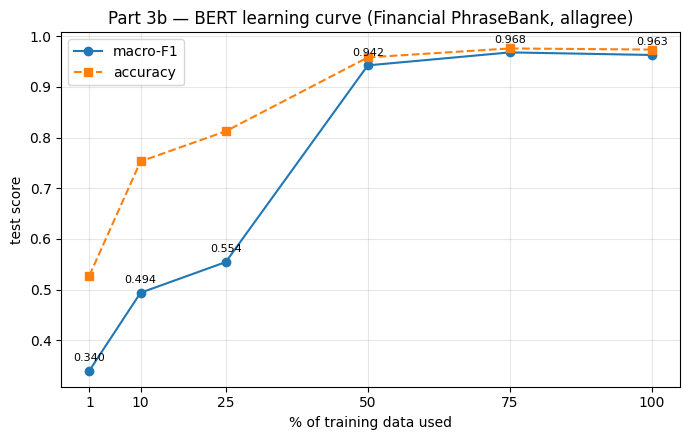

,method,pct,n_train_labeled,accuracy,f1_macro,f1_weighted
0,full-1%,1,18,0.527594,0.340054,0.501935
1,full-10%,10,181,0.752759,0.493675,0.701604
2,full-25%,25,452,0.812362,0.554239,0.764836
3,full-50%,50,905,0.958057,0.942317,0.958250
4,full-75%,75,1358,0.975717,0.967908,0.975795
5,full-100%,100,1811,0.973510,0.962818,0.973579


In [17]:
# watermark: AGLLM (AI-assisted content disclosure)
# Part 3b: BERT learning curve — test macro-F1 and accuracy as a function of the
# percentage of training data used. Reads the data-scaling rows that 3a logs to the
# shared scoreboard, so it also works after a kernel restart (no need to keep 3a's
# in-memory results around).
import matplotlib.pyplot as plt

res = pd.read_csv(eu.RESULTS_CSV)
curve = res[(res['model'] == MODEL) & res['method'].str.startswith('full-')].copy()
# 'full-25%' -> 25, the percentage of `train` used for that point.
curve['pct'] = curve['method'].str.extract(r'full-(\d+)%').astype(int)
# Keep the most recent row per percentage, in case an older train size left stale rows.
curve = curve.drop_duplicates('pct', keep='last').sort_values('pct')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(curve['pct'], curve['f1_macro'], marker='o', label='macro-F1')
ax.plot(curve['pct'], curve['accuracy'], marker='s', ls='--', label='accuracy')
for _, r in curve.iterrows():
    ax.annotate(f"{r['f1_macro']:.3f}", (r['pct'], r['f1_macro']),
                textcoords='offset points', xytext=(0, 7), fontsize=8, ha='center')
ax.set_xlabel('% of training data used')
ax.set_ylabel('test score')
ax.set_title('Part 3b — BERT learning curve (Financial PhraseBank, allagree)')
ax.set_xticks(curve['pct'])
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

curve[['method', 'pct', 'n_train_labeled', 'accuracy', 'f1_macro', 'f1_weighted']].reset_index(drop=True)

Caveats (defense-proofing)
This is a single-seed experiment, so the 25%→50% jump could shift with the seed; averaging over at least three seeds would be more reliable.
The protocol is deliberately light (3 epochs, max_len 64) for CPU tractability, and more epochs would likely lift the small-fraction points and soften the transition.
The subsets are independent rather than strictly nested, so the small-N points are noisy.
Evaluation was carried out only on the allagree test split.
3c / 3d status
3c: The scoreboard now carries all the cross-technique points — Person B's 32-shot (0.601), the back-translation run (2b, 0.635), the LLM-generated run (2d, 0.841), and the six curve points, alongside Person C's LLM zero-shot and few-shot results. Re-running 3b overlays each Part-2 technique on the curve at the number of training rows it used, with the LLM drawn as a horizontal reference far above the BERT curve. The 2e point (the combined "optimal" set, 585 rows) is also logged now, at 0.800 macro-F1 — notably below 2d, since pooling the back-translation paraphrases with the generated data added noise.
3d (methodology analysis): The dimensions are set out in Part3_SOA_guidance.md, and the substantive comparison is the effectiveness-by-data-regime story above: with 0 labels the LLM zero-shot leads (0.978, but watch contamination); at ~32 real labels plain fine-tuned BERT (0.60) loses to the rules (0.73), yet adding LLM-generated data lifts BERT to 0.841 and past the lexicon; and with abundant labels fine-tuned BERT reaches 0.96. Each method is the right tool in a different regime, and cost, latency, and controllability separate the local BERT from the API LLM. The 2d result also sharpens the data-efficiency reading: roughly 360 synthetic examples carried BERT from 0.60 to 0.84, doing the work that hundreds of additional real labels would otherwise require.


### 3c — technique comparison &nbsp;·&nbsp; 3d — methodology analysis

**3c (fold in Part 2 techniques):** the cell above overlays every Part 2 row logged in `results/results.csv` (`32-shot`, `augmented`, `llm-generated`, `optimal-combo`) on the data-scaling curve, each plotted at the number of training rows it used — i.e.‍ "how many real labels is each technique worth?".‍ Points appear automatically as 2d/2e get logged; re-run the cell after they finish.